# Simulated Annealing Tutorial ーEquality Constraintsー

This notebook explains how to use equality constraints.
To approach this topic, we will examine the portfolio optimization problem and provide sample code.

## Preparation

In [ ]:
!pip install openjij
!pip install pyqubo

In [ ]:
import numpy as np

In [ ]:
import openjij as oj

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from pyqubo import Array, Constraint, Placeholder

## Define the problem

Portfolio optimization involves finding the optimal combination of stocks for investment, taking into account both risk and return.

To simplify the formulation, we consider a situation where we wish to diversify investments across $M$ stocks selected from $N$ stocks, choosing only whether to buy or not buy each stock.

Let $C_1, \dots, C_N$ denote the returns of each stock. This problem can be formulated as follows:

$$
{\text{min}} \,\,\,( \sum_{i = 1}^N C_ix_i - \lambda (\sum_{i = 1}^N C_i - M)^2)
$$

Here, the second term is called the penalty term.
It is expressing the equality constraint that the number of stocks to buy is M in a form suitable for QUBO formulation.

In [ ]:
N = 10  # problem size
C_min = 1  # minimum return
C_max = 10  # maximum return
C = np.random.randint(low=C_min, high=C_max, size=N)
M = 4  # equality costraint

print(f"{C=}")

C=array([3, 8, 6, 4, 4])


## Formulate

We use pyqubo(https://pyqubo.readthedocs.io/en/latest/) to construct the above formulation.
(You may use other methods.)

In [ ]:
# variable values
x = Array.create('',shape=N, vartype='BINARY')

# objective function
H_1 = -sum(C[i]*x[i] for i in range (N))

# equality costraint
H_2 = Constraint((sum(x)-M)**2, "lambda")

# Hamiltonian
H = H_1 + Placeholder("lambda")*H_2

# compile to a model
model = H.compile()

# specify the coefficient lambda and convert it to QUBO
feed_dict = {"lambda": 20}
qubo_dict, offset = model.to_qubo(feed_dict=feed_dict)

In [ ]:
print(x)
print(qubo_dict)

Array([Binary('[0]'), Binary('[1]'), Binary('[2]'), Binary('[3]'), Binary('[4]')])
{('[1]', '[1]'): -68.0, ('[4]', '[0]'): 40.0, ('[0]', '[0]'): -63.0, ('[3]', '[3]'): -64.0, ('[4]', '[2]'): 40.0, ('[4]', '[1]'): 40.0, ('[4]', '[3]'): 40.0, ('[2]', '[2]'): -66.0, ('[3]', '[2]'): 40.0, ('[1]', '[0]'): 40.0, ('[3]', '[0]'): 40.0, ('[2]', '[1]'): 40.0, ('[3]', '[1]'): 40.0, ('[2]', '[0]'): 40.0, ('[4]', '[4]'): -64.0}


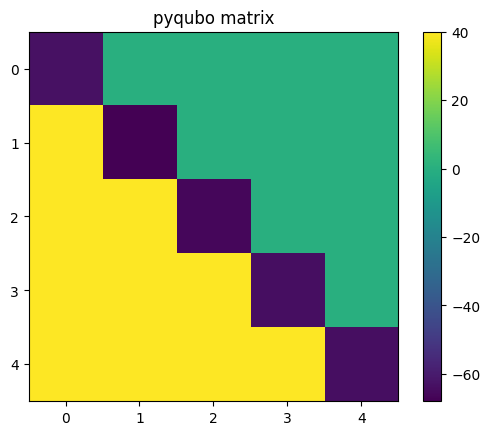

In [ ]:
import re
# Show QUBO heatmap
QUBO = np.zeros((N,N))
for (x_i,x_j) in qubo_dict.keys():
    i = int(re.findall(r'\d+', x_i)[0])
    j = int(re.findall(r'\d+', x_j)[0])
    QUBO[i][j] = qubo_dict[(x_i,x_j)]

plt.imshow(QUBO)
plt.colorbar()
plt.title('pyqubo matrix')
plt.show()

## Solve the problem with SA

In [ ]:
# Conduct Simulated Annealing
num_reads = 300
num_sweeps = 1000
sampler = oj.SASampler()
sampleset = sampler.sample_qubo(QUBO, num_reads=num_reads, num_sweeps=num_sweeps)

In [ ]:
# Obtain the solution of minimum objective value
x_star = np.array([sampleset.first.sample[i] for i in range(N)])

Finally, let's check the results.

In [ ]:
# See the result
print(f"{x_star=}")
print(f"{C@x_star=}")

x_star=array([0, 1, 1, 0, 0], dtype=int8)
C@x_star=np.int64(14)


If the optimul solution breaks the equality_constraints, you should increase lambda value.

# [Step up] How to represent discrete values

When diversifying investments to account for risk, no one thinks only two options: buy or not. Moving forward, we will focus on how to represent discrete values on QUBO.